In [1]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation

from IPython.display import HTML, Image

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

 



From the partial tracking we have three matrices that describe the evolution of a sound over time:

- The frequency matrix:
$
\mathbf F_{n,i}
$

- The amplitude matrix:
$
\mathbf A_{n,i}
$

- The phase matrix:
$
\mathbf P_{n,i}
$

Each of these matrices has a the time along one dimension, with the **frame index** $n$,
and the partials along the other dimension, with the **partial index** $i$.



-----

# Oscillator Bank

The simplest way to re-synthesize a sound after the analysis process is in the time-domain -
with an **oscillator bank** - which is basically an array of oscillators.
In this case we are ignoring the original phase from the analysis.

The figure below shows this for an example with three partials.
Each oscillator is driven with its frequency trajectory $f_i(t)$ of a single partial.
Each partial's gain is then controlled by the relevant partial amplitude trajectory $a_i(t)$.
The resulting components are then added to create the complete harmonic signal $y(t)$.

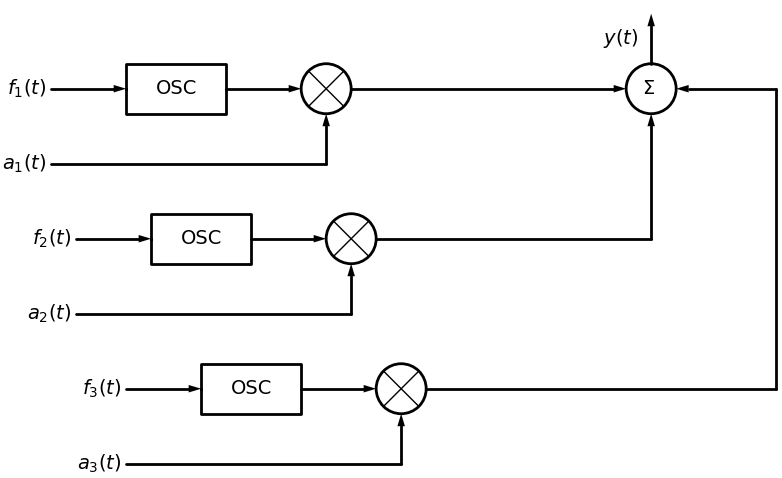

In [2]:
with schemdraw.Drawing() as d:

    
    d.push
    d.config(fontsize=14)
    dsp.Arrow().length(d.unit/2).label('$f_1(t)$','left')
    h1 = dsp.Box(w=2, h=1).label('OSC')
    dsp.Arrow().length(d.unit/2)
    m1 = dsp.Mixer()

    d.pop
    d.move(dx=-6, dy=-1.5)
    dsp.Line().length(5.5).label('$a_1(t)$','left')
    dsp.Arrow().up().length(1)

    dsp.Arrow().at(m1.E).right().length(5.5)
    sig = dsp.SumSigma()


    d.push
    d.move(dx=-12, dy=-3)
    dsp.Arrow().length(d.unit/2).label('$f_2(t)$','left')
    h1 = dsp.Box(w=2, h=1).label('OSC')
    dsp.Arrow().length(d.unit/2)
    m1 = dsp.Mixer()

    d.pop
    d.move(dx=-6, dy=-1.5)
    dsp.Line().length(5.5).label('$a_2(t)$','left')
    dsp.Arrow().up().length(1)

    dsp.Line().at(m1.E).right().length(5.5)
    dsp.Arrow().up().length(2.5)
 

    d.push
    d.move(dx=-10.5, dy=-5.5)
    dsp.Arrow().right().length(d.unit/2).label('$f_3(t)$','left')
    h1 = dsp.Box(w=2, h=1).label('OSC')
    dsp.Arrow().length(d.unit/2)
    m1 = dsp.Mixer()

    d.pop
    d.move(dx=-6, dy=-1.5)
    dsp.Line().length(5.5).label('$a_3(t)$','left')
    dsp.Arrow().up().length(1)
   

    dsp.Line().at(m1.E).right().length(7)
    dsp.Line().up().length(6)   
    dsp.Arrow().left().length(2)   

    dsp.Arrow().at(sig.N).up().length(1).label('$y(t)$','top')  



-----

# Trajectory Interpolation

Our matrices $F_{n,i}$ and $A_{n,i}$ have values only for each STFT frame of the analysis process.
They are $L_{HOP}$ samples apart.
That means we need to interpolate all partial control trajectories ($f_i(t)$ and $a_i(t)$) between these support.

The following plot shows how a partial amplitude trajectory $a_i(t)$ is created through interpolation from matrix values, with an analysis hop-size of $0.1$ seconds:  

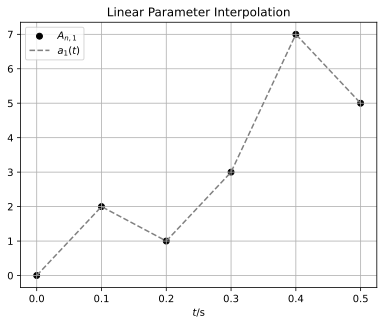

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Define discrete data points
t = np.array([0, 1, 2, 3, 4, 5])  # Time or x-axis values
y = np.array([0, 2, 1, 3, 7, 5])  # Signal values

# Create linear interpolation function
interp_func = interp1d(t, y, kind='linear')

# Generate fine-grained x values for smooth interpolation
t_fine = np.linspace(0, 5, 100)
y_fine = interp_func(t_fine)

# Plot original data points and interpolated signal
plt.scatter(t/10, y, color='black', label='$A_{n,1}$')
plt.plot(t_fine/10, y_fine, 'gray',label='$a_1(t)$', linestyle='--')
plt.xlabel('$t$/s')
#plt.ylabel('$x_i(t)$')
plt.legend()
plt.title('Linear Parameter Interpolation')
plt.grid(True)
plt.show()
